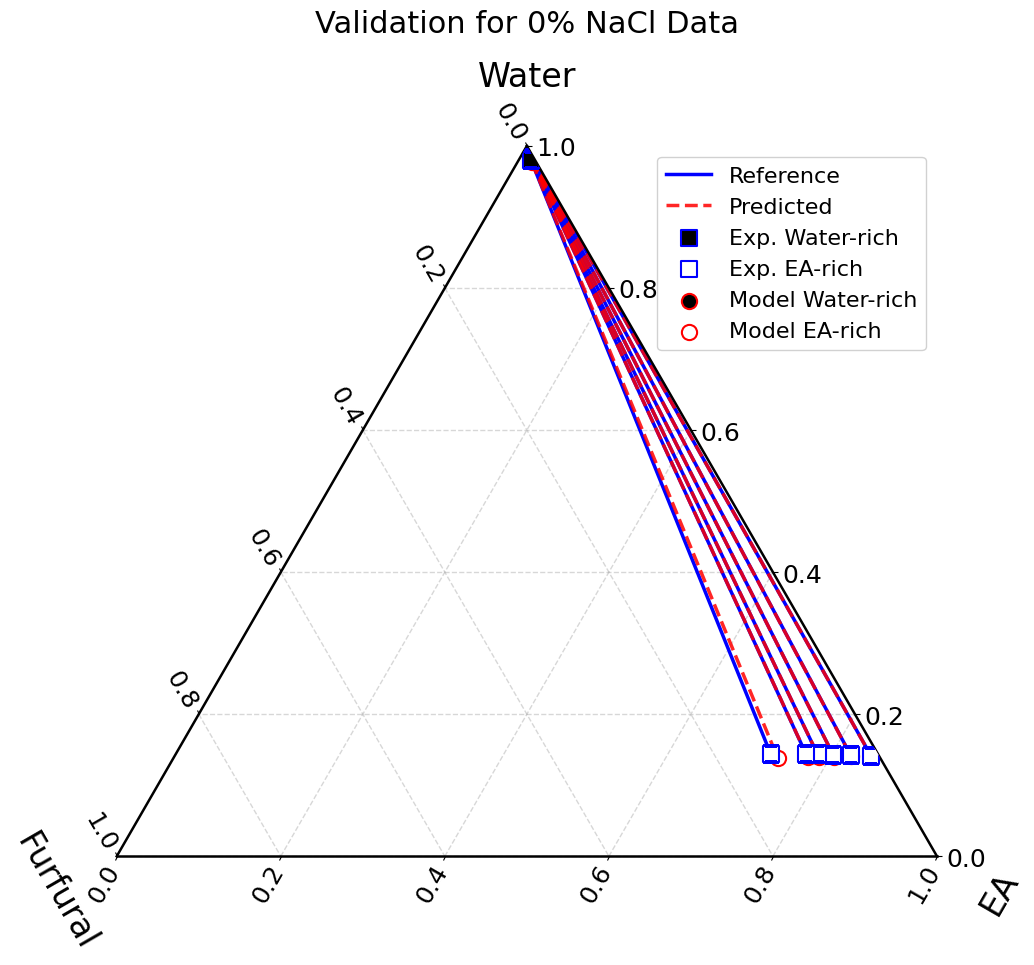

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_0.png


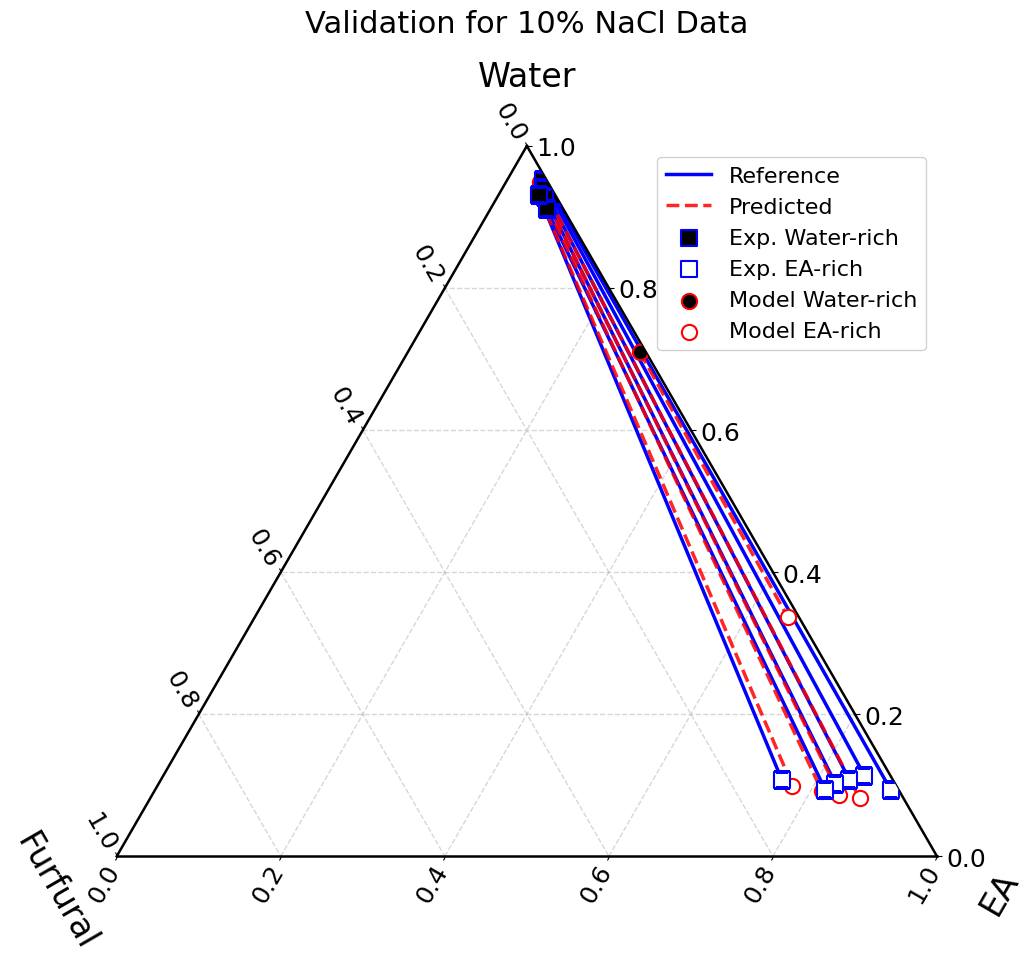

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_10.png


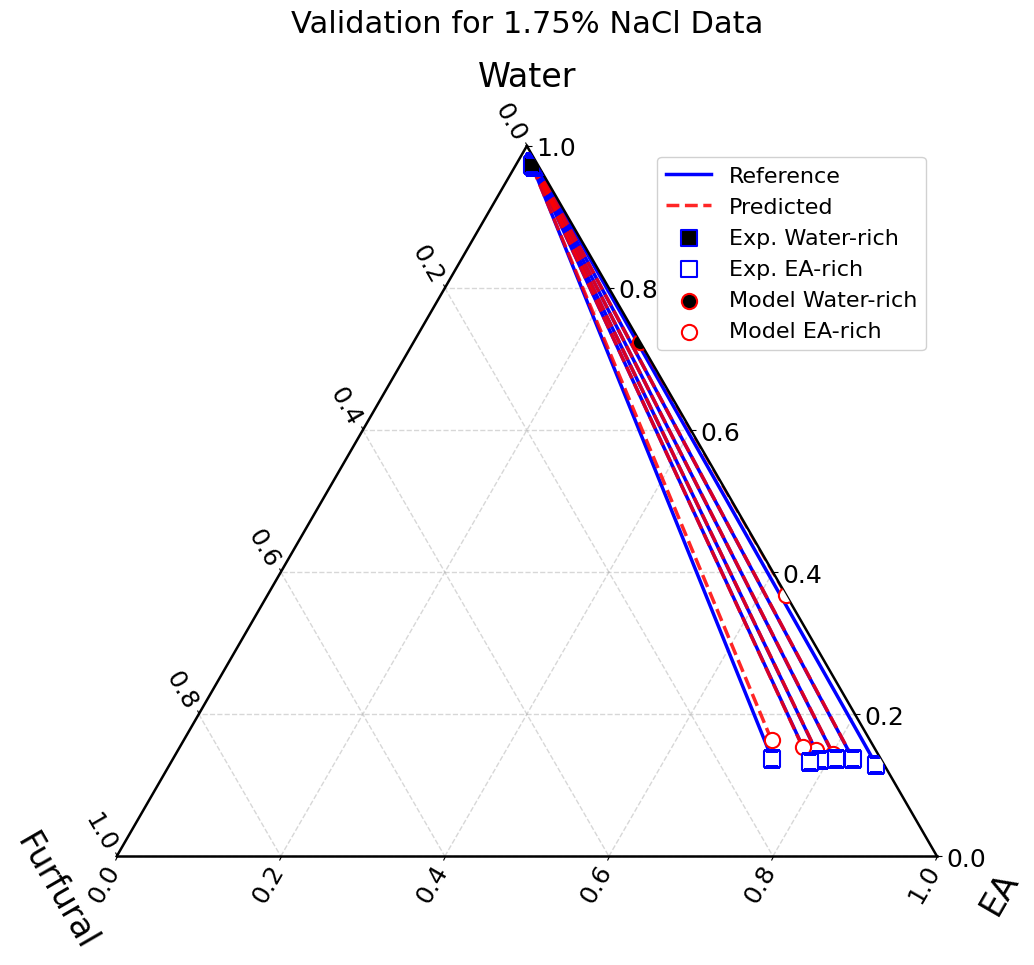

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_1.75.png


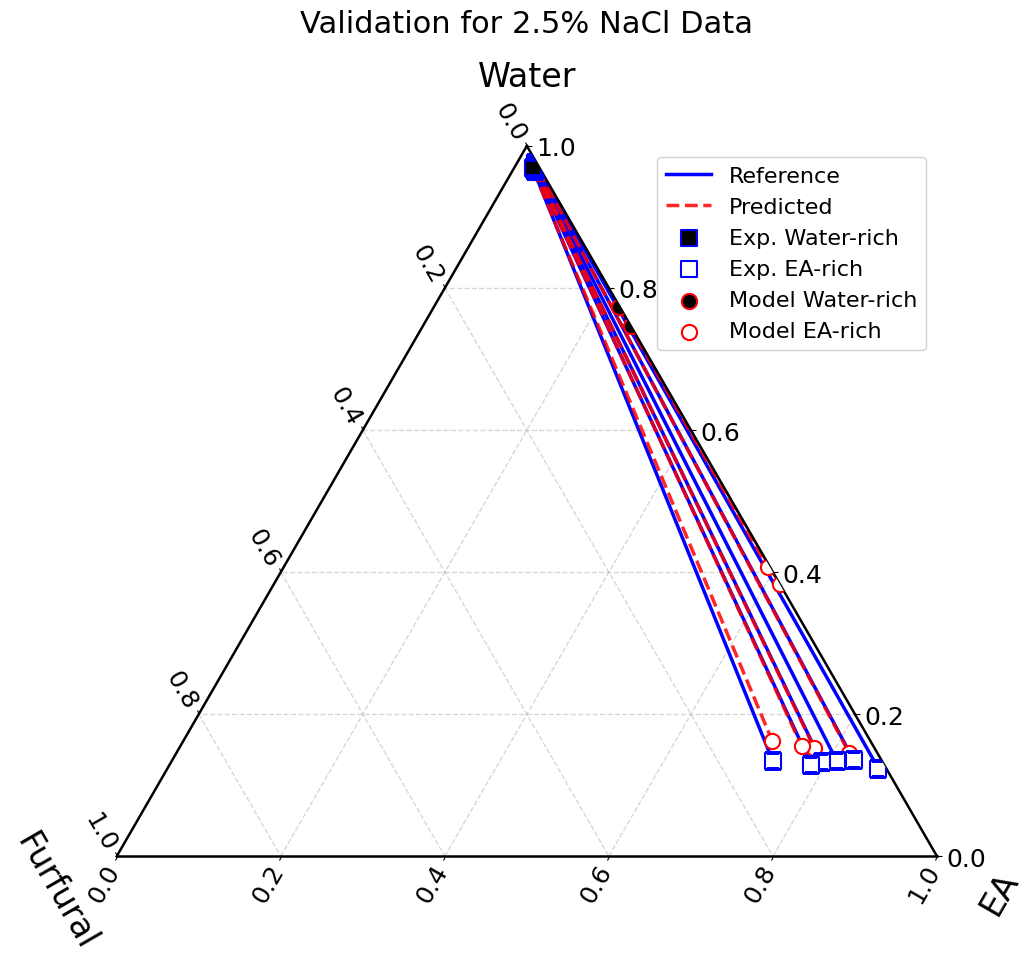

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_2.5.png


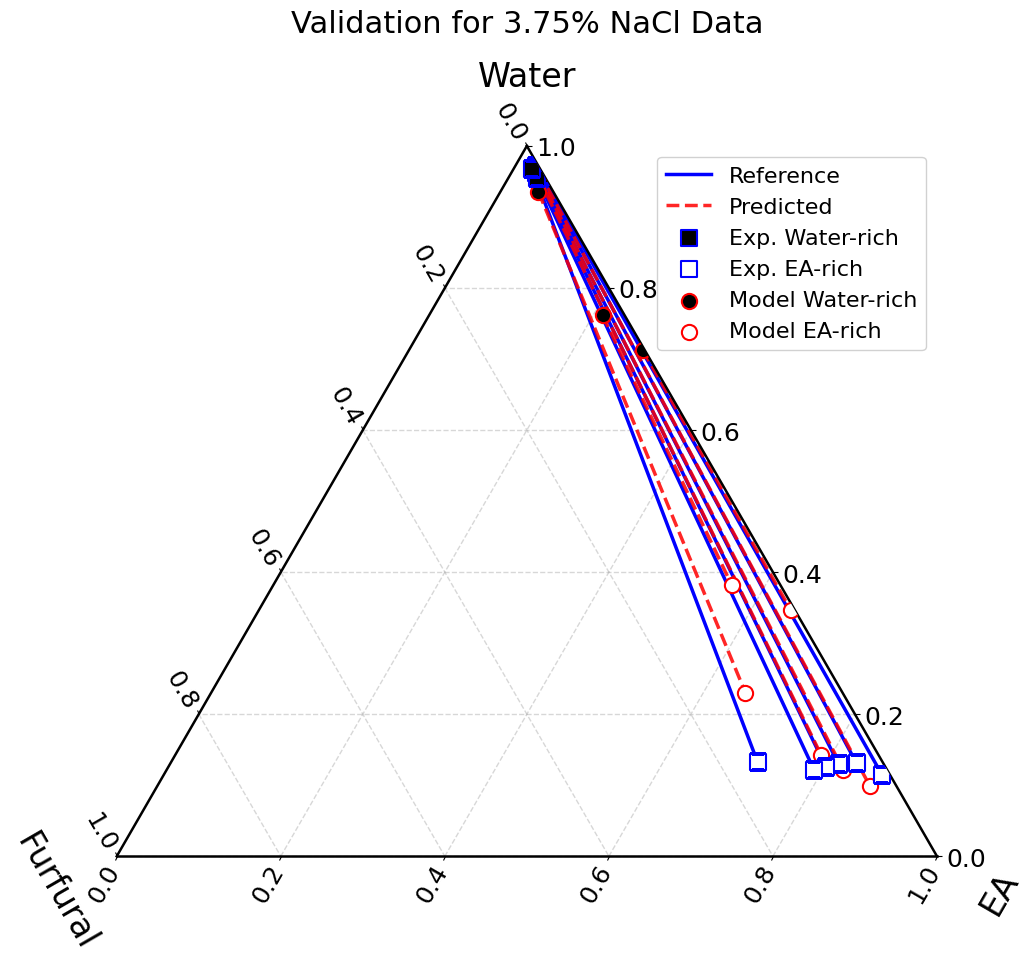

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_3.75.png


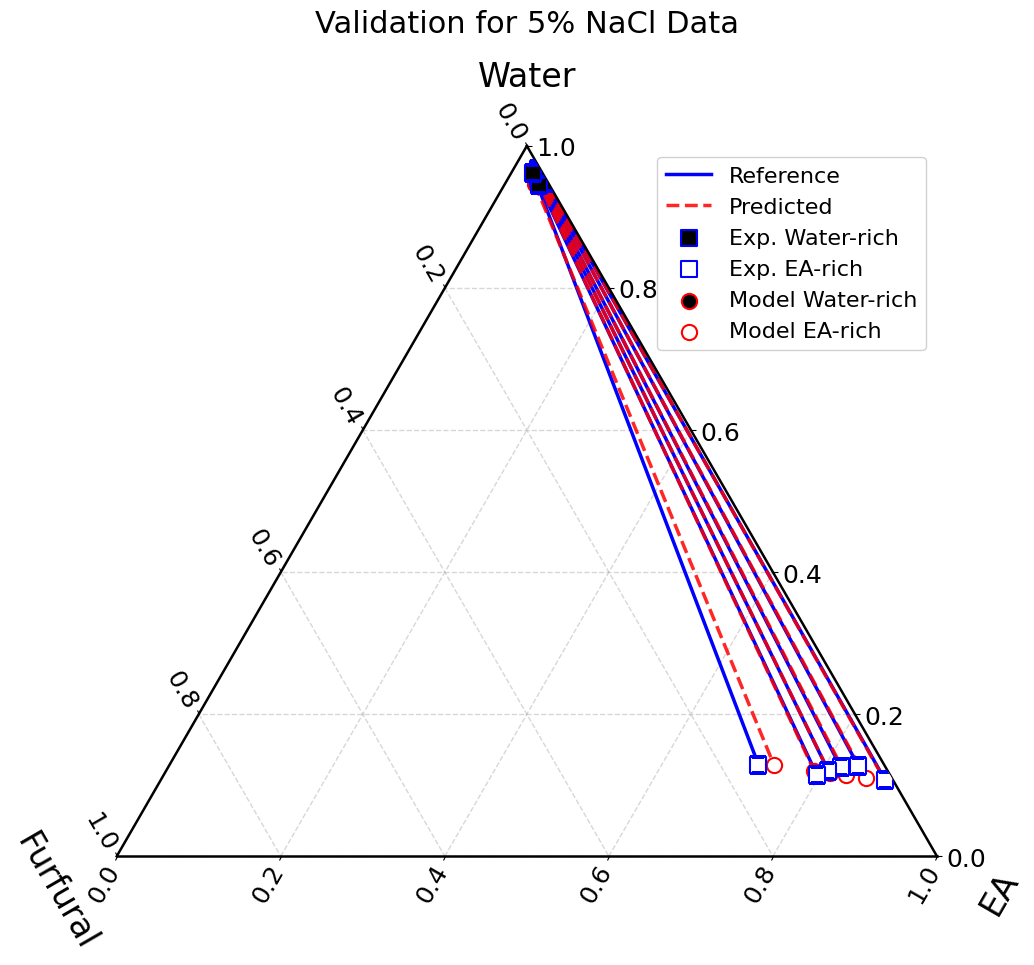

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_5.png


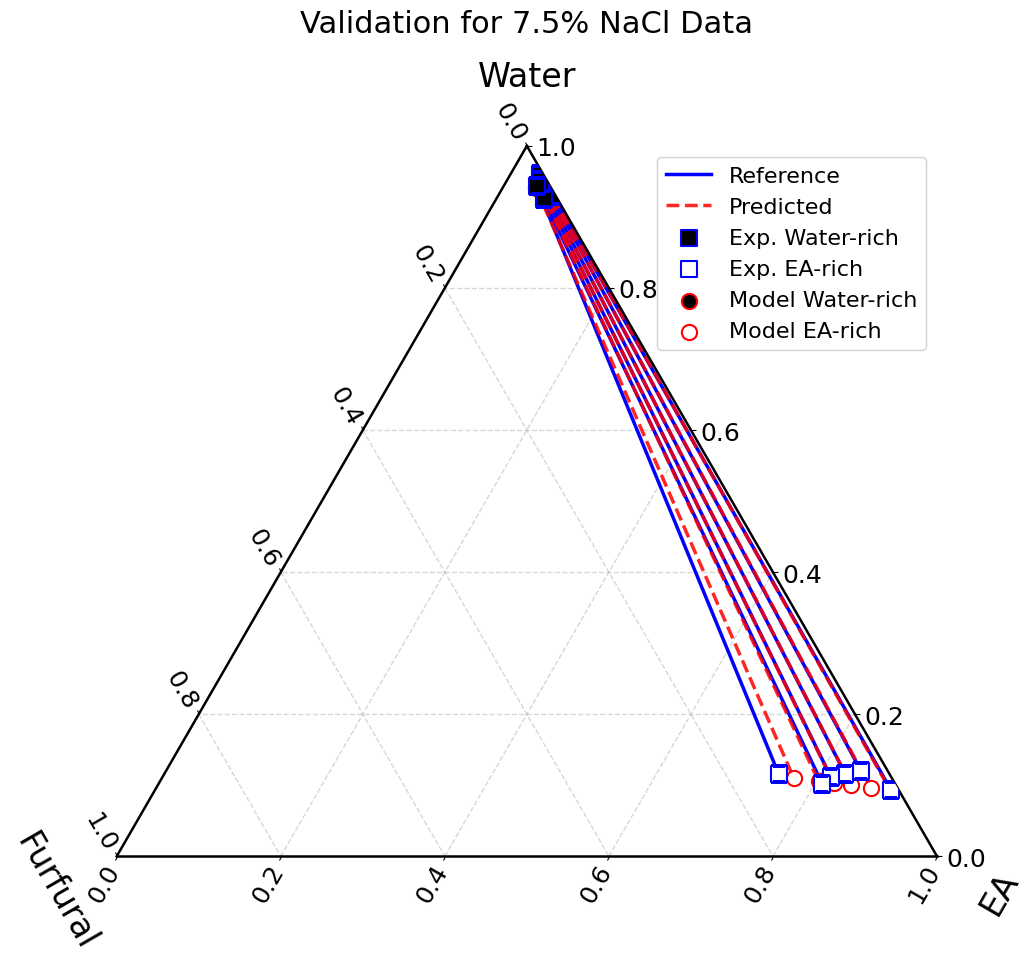

Saved: ValidationDiagram_InterpolatedTrainingSet/validation_diagram_7.5.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import mpltern
import matplotlib as mpl
import glob
import os


mpl.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

DATA_DIR = "BaselineValidationData"
OUTPUT_DIR = "ValidationDiagram_InterpolatedTrainingSet"

os.makedirs(OUTPUT_DIR, exist_ok=True)

exp_files = sorted(glob.glob(os.path.join(DATA_DIR, "exp_validation_data_*.csv")))

for exp_file in exp_files:

    suffix = os.path.basename(exp_file).replace("exp_validation_data_", "")
    model_file = os.path.join(DATA_DIR, f"model_validation_data_{suffix}")

    exp_df = pd.read_csv(exp_file)
    model_df = pd.read_csv(model_file) if os.path.exists(model_file) else pd.DataFrame()

    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(projection="ternary")

    ax.set_tlabel("Water")
    ax.set_llabel("Furfural")
    ax.set_rlabel("EA")

    ax.grid(True, linestyle="--", alpha=0.5, linewidth=1)

    ax.taxis.set_tick_params(labelsize=18)
    ax.laxis.set_tick_params(labelsize=18)
    ax.raxis.set_tick_params(labelsize=18)

    # Thicker triangle border
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    for i,row in exp_df.iterrows():
        ax.plot(
            [row["water_rich_w"], row["ea_rich_w"]],
            [row["water_rich_f"], row["ea_rich_f"]],
            [row["water_rich_e"], row["ea_rich_e"]],
            color="blue",
            linewidth=2.5,
            label="Reference" if i==0 else ""
        )

    if not model_df.empty:
        for i,row in model_df.iterrows():
            ax.plot(
                [row["water_rich_w"], row["ea_rich_w"]],
                [row["water_rich_f"], row["ea_rich_f"]],
                [row["water_rich_e"], row["ea_rich_e"]],
                color="red",
                linestyle="--",
                linewidth=2.5,
                alpha=0.85,
                label="Predicted" if i==0 else ""
            )

    ax.scatter(
        exp_df["water_rich_w"],
        exp_df["water_rich_f"],
        exp_df["water_rich_e"],
        marker="s",
        s=120,
        color="black",
        edgecolors="blue",
        linewidths=1.5,
        zorder=5,
        label="Exp. Water-rich"
    )

    ax.scatter(
        exp_df["ea_rich_w"],
        exp_df["ea_rich_f"],
        exp_df["ea_rich_e"],
        marker="s",
        s=120,
        color="white",
        edgecolors="blue",
        linewidths=1.5,
        zorder=5,
        label="Exp. EA-rich"
    )

    if not model_df.empty:

        ax.scatter(
            model_df["water_rich_w"],
            model_df["water_rich_f"],
            model_df["water_rich_e"],
            marker="o",
            s=120,
            color="black",
            edgecolors="red",
            linewidths=1.5,
            zorder=4,
            label="Model Water-rich"
        )

        ax.scatter(
            model_df["ea_rich_w"],
            model_df["ea_rich_f"],
            model_df["ea_rich_e"],
            marker="o",
            s=120,
            color="white",
            edgecolors="red",
            linewidths=1.5,
            zorder=4,
            label="Model EA-rich"
        )

    salt_label = suffix.replace(".csv","").replace("_",".")
    ax.set_title(f"Validation for {salt_label}% NaCl Data", pad=20)

    ax.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()

    save_path = os.path.join(
        OUTPUT_DIR,
        f"validation_diagram_{salt_label}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")